In [1]:
import pandas as pd
import numpy as np
import zipfile

zip_path = "preprocessed_data1.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("preprocessed_data1.csv") as f:
        prep_df = pd.read_csv(f)

print(prep_df.shape)

(39119, 12)


In [2]:
prep_df1 = prep_df[prep_df['preamble'].notna() & prep_df['description'].notna() & prep_df['sentence'].notna()]
prep_df1.shape

(39119, 12)

In [3]:
df_with_marking = pd.read_csv("df_with_marking_final.csv")
df_with_marking

,id,region,entryDate,names,judge,decision,accused,articles,link_text,gender_accused,...,preamble,description,sentence,victim_count,killer_count,extracted_prison_term,prison_term_re,num_victims,has_woman_victim,has_man_victim
0,57844,29,2018-05-11,Газизов Дмитрий Рустамович - ст.105 ч.1 УК РФ,Аршинов Алексей Александрович,Вынесен ПРИГОВОР,Газизов Дмитрий Рустамович,ст.105 ч.1,http://lomonosovsky--arh.sudrf.ru/modules.php?...,мужчина,...,Дело <№> (29RS0<№>-58)\nПРИГОВОР\nименем Росси...,УСТАНОВИЛ:\nГ.Д.Р. совершил убийство при следу...,ПРИГОВОРИЛ:\nГ.Д.Р. признать виновным в соверш...,1,1,NaN,6.0,1,0,1
1,71745,23,2019-08-26,"Жмурко Юрий Геннадьевич - ст.167 ч.1, ст.105 ч...",Сапега Н.Н.,Вынесен ПРИГОВОР,Жмурко Юрий Геннадьевич,"ст.167 ч.1, ст.105 ч.1",http://novopokrovsky--krd.sudrf.ru/modules.php...,мужчина,...,К делу № 1-141/2019 г.\nПРИГОВОР\nИменем Росси...,"УСТАНОВИЛ:\nЖмурко Ю.Г. совершил убийство, т.е...",ПРИГОВОРИЛ:\nПризнать Жмурко Юрия Геннадьевича...,1,1,NaN,8.0,1,0,1
2,41579,50,2017-06-30,"Скворцов Евгений Владимирович - ст.325 ч.1, ст...",Мядзелец О.А.,Вынесен ПРИГОВОР,"Скворцов Евгений Владимирович, Скородумов Серг...","ст.325 ч.1, ст.325 ч.1, ст.325 ч.2, ст.162 ч.4...",http://oblsud--mo.sudrf.ru/modules.php?name=su...,"['мужчина', 'мужчина']",...,ПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИИ\n25 дека...,УСТАНОВИЛ:\nВердиктом коллегии присяжных засед...,ПРИГОВОРИЛ:\nСкородумова Сергея Юрьевича призн...,2,2,NaN,2017.0,2,1,0
3,116462,50,2022-05-04,"Матвеев Сергей Владимирович - ст. 30 ч.3, ст.1...",Перминова Е.А.,Вынесен ПРИГОВОР,Матвеев Сергей Владимирович,"ст. 30 ч.3, ст.105 ч.1",http://volokolamsk--mo.sudrf.ru/modules.php?na...,мужчина,...,Решение по уголовному делу\nИнформация по делу...,УСТАНОВИЛ:\nМатвеев С.В. совершил умышленное п...,ПРИГОВОРИЛ:\nпризнать виновным в совершении пр...,1,1,NaN,3.0,1,0,1
4,102232,38,2021-04-19,Шамов Сергей Викторович - ст.105 ч.1 УК РФ,Иванов Д.В.,Вынесен ПРИГОВОР,Шамов Сергей Викторович,ст.105 ч.1,http://angarsky--irk.sudrf.ru/modules.php?name...,мужчина,...,ПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИИ\nг.Ангар...,У С Т А Н О В И Л:\nНа основании вердикта колл...,ПРИГОВОРИЛ:\nПризнать Ш.С.В. виновным в соверш...,1,1,9.25,9.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,122495,78,2022-03-01,"ТАРАКАНОВ ВЛАДИМИР ВЛАДИМИРОВИЧ - ст. 30 ч.3, ...",Гулевич Станислав Анатольевич,Вынесен ПРИГОВОР,Тараканов Владимир Владимирович,"ст. 30 ч.3, ст.105 ч.1",http://nvs--spb.sudrf.ru/modules.php?name=sud_...,мужчина,...,Дело № 1-589/22 (78 BS 0015-01-2022-00231414)\...,У С Т А Н О В И Л :\nПодсудимый Тараканов В.В....,П Р И Г О В О Р И Л :\nПризнать Тараканова Вла...,1,1,NaN,4.0,1,0,1
96,79171,60,2018-12-04,Немтинов Сергей Викторович - ст.105 ч.1 УК РФ,Сергеева Надежда Николаевна,Вынесен ПРИГОВОР,Немтинов Сергей Викторович,ст.105 ч.1,http://pskovsky--psk.sudrf.ru/modules.php?name...,мужчина,...,Дело ***\nПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИ...,"УСТАНОВИЛ:\nНемтинов С.В. совершил убийство, т...",ПРИГОВОРИЛ:\nПризнать Немтинова Сергея Викторо...,1,1,NaN,2019.0,1,1,0
97,31607,24,2017-07-31,Баженов Дмитрий Викторович - ст.105 ч.1 УК РФ,Безрукова Ольга Васильевна,Вынесен ПРИГОВОР,Баженов Дмитрий Викторович,ст.105 ч.1,http://igarka--krk.sudrf.ru/modules.php?name=s...,мужчина,...,Дело №\nП Р И Г О В О Р\nИменем Российской Фед...,У С Т А Н О В И Л:\nБаженов Д.В. совершил убий...,П Р И Г О В О Р И Л:\nБаженова Д.В. признать в...,1,1,NaN,2017.0,1,1,0
98,14640,50,2016-01-11,Меликян Тарон Акопи - ст.105 ч.1 УК РФ,Попова Марина Николаевна,Вынесен ПРИГОВОР,Меликян Тарон Акопи,ст.105 ч.1,http://luberetzy--mo.sudrf.ru/modules.php?name...,мужчина,...,Дело №\nПРИГОВОР\nименем Российской Федерации\...,"УСТАНОВИЛ:\nМеликян Т.А. совершил убийство, то...",ПРИГОВОРИЛ:\nМеликяна Т. А. признать виновным ...,1,1,NaN,8.0,1,1,0


In [4]:
import re

def count_killers(names_text: str) -> int:
    text = names_text.replace('\n', ' ').replace('\r', ' ').strip()

    people = re.split(r'\s*,\s*(?=[^,]*?\s*-\s*ст\.)', text)

    count = 0
    for person in people:
        # print(person)
        if '105' in person:
            count += 1
    # print("end")
    return count

In [5]:
df_with_marking['killer_count'] = df_with_marking['names'].apply(count_killers)

In [6]:
df_with_marking.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'gender_accused', 'alcohol', 'drugs',
       'mental_disorder', 'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'preamble', 'description', 'sentence', 'victim_count',
       'killer_count', 'extracted_prison_term', 'prison_term_re',
       'num_victims', 'has_woman_victim', 'has_man_victim'],
      dtype='object')

In [7]:
# import pandas as pd
# import numpy as np
# import zipfile

# zip_path = "sampled_data.zip"

# with zipfile.ZipFile(zip_path, "r") as z:
#     with z.open("sampled_data.csv") as f:
#         df_3000 = pd.read_csv(f)

# print(df_3000.shape)
df_3000 = pd.read_csv('3k_3.csv')

In [8]:
df_3000.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'killer_count', 'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term', 'predictions2',
       'predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive',
       'predicted_relationship', 'predicted_has_woman_victim',
       'predicted_has_man_victim', 'clean_description3', 'predictions3',
       'predicted_time_of_day', 'predicted_location', 'predicted_method',
       'predicted_relationship3'],
      dtype='object')

In [9]:
df_no_marking = prep_df[(~prep_df['id'].isin(df_with_marking['id'])) & (~prep_df['id'].isin(df_3000['id']))]
df_no_marking.shape

(36019, 12)

# Предобработка

In [10]:
df_3000 = df_3000[~df_3000['id'].isin(df_with_marking['id'])]
df_3000.shape

(3000, 31)

In [11]:
full_df = df_no_marking.sample(n=7000, random_state=42)
full_df = pd.concat([full_df, df_with_marking, df_3000])
full_df.shape

(10100, 57)

In [12]:
# df_with_marking1 = full_df[full_df['id'].isin(df_with_marking['id'])]
# df_with_marking1.shape

In [13]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=1000, height=500):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

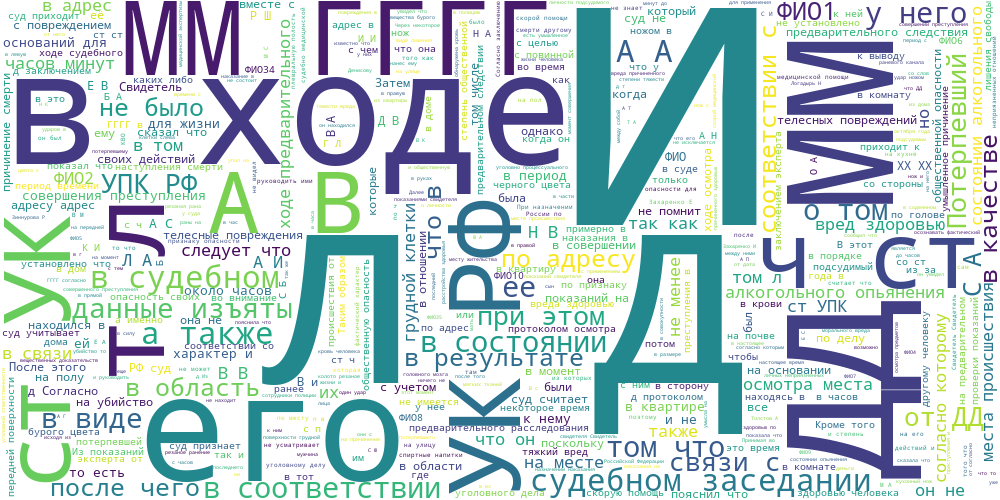

In [14]:
draw_wordcloud(df_with_marking.description)

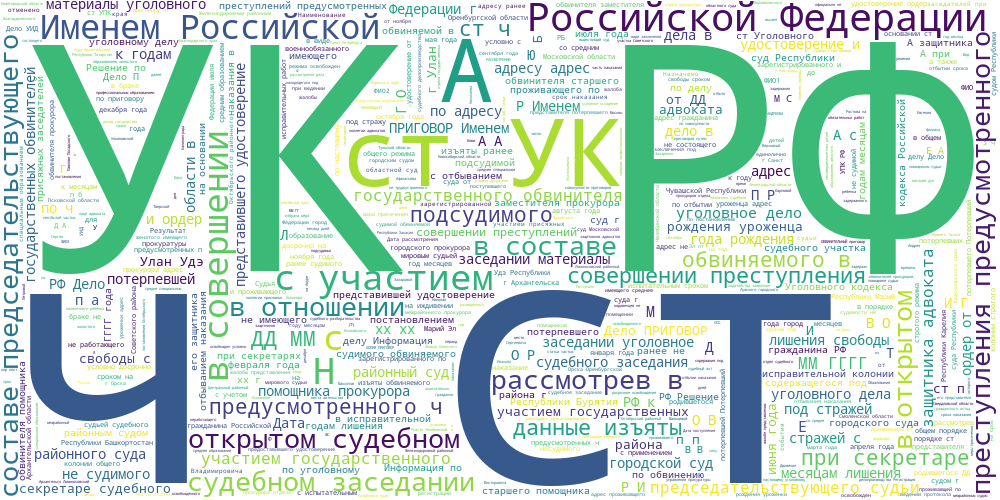

In [15]:
draw_wordcloud(df_with_marking.preamble)

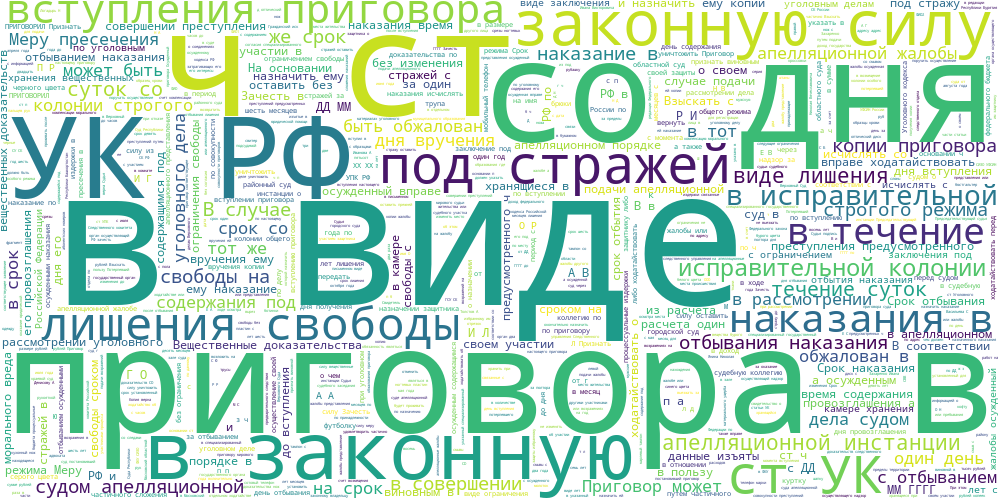

In [16]:
draw_wordcloud(df_with_marking.sentence)

In [17]:
import re
import pymorphy3
from nltk.corpus import stopwords
import nltk
from tqdm import tqdm
from functools import lru_cache

nltk.download("stopwords")
custom_stopwords = set([
    "в", "мм", "гггг", "дд", "ук", "рф", "ст", "д", "и", "ч", "ходе", "т", "л"
])

all_stopwords = set(stopwords.words("russian")).union(custom_stopwords)
morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=100000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

def preprocess_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    words = text.split()
    
    lemmas = [lemmatize_word(word) for word in words if word not in all_stopwords]
    return " ".join(lemmas)

tqdm.pandas()
full_df["tfidf_description_prep"] = full_df["description"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_preamble_prep"] = full_df["preamble"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_sentence_prep"] = full_df["sentence"].astype(str).progress_apply(preprocess_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zephyrus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 10100/10100 [00:05<00:00, 1948.09it/s]


In [18]:
import re
import pymorphy3
from nltk.corpus import stopwords
import nltk
from tqdm import tqdm

nltk.download("stopwords")
custom_stopwords = set([
    "в", "мм", "гггг", "дд", "ук", "рф", "ст", "д", "и", "ч", "ходе", "т", "л"
])

all_stopwords = set(stopwords.words("russian")).union(custom_stopwords)
morph = pymorphy3.MorphAnalyzer()

def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

def preprocess_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    return text

tqdm.pandas()
full_df["tfidf_description_prep_no_lemma"] = full_df["description"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_preamble_prep_no_lemma"] = full_df["preamble"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_sentence_prep_no_lemma"] = full_df["sentence"].astype(str).progress_apply(preprocess_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zephyrus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 10100/10100 [00:01<00:00, 6524.84it/s]


In [19]:
def preprocess_text_w2v(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()

    words = text.split()
    return [word for word in words if word not in all_stopwords and len(word) > 1]

tqdm.pandas()
full_df["w2v_description_prep"] = full_df["description"].astype(str).progress_apply(preprocess_text_w2v)
full_df["w2v_preamble_prep"] = full_df["preamble"].astype(str).progress_apply(preprocess_text_w2v)
full_df["w2v_sentence_prep"] = full_df["sentence"].astype(str).progress_apply(preprocess_text_w2v)

100%|██████████| 10100/10100 [00:02<00:00, 3687.44it/s]


In [20]:
extracted_features = ["gender_accused", "alcohol", "drugs", "prior_convictions",
    "relationship_between_accused_and_victim",
    "time_of_day", "location",
    "method", "motive",
    "precrime_argument", "prison_term", "has_woman_victim", "has_man_victim"]
len(extracted_features)

13

In [21]:
description_features = ["gender_accused", "alcohol", "drugs",
                        "relationship_between_accused_and_victim", 
                        "time_of_day", "location", "method", "motive", "precrime_argument", "has_woman_victim", "has_man_victim"]
sentence_features = ["prison_term"]

preamble_desctiption_features = ["prior_convictions"]

len(description_features), len(sentence_features), len(preamble_desctiption_features)

(11, 1, 1)

In [22]:
features_accused = ["gender_accused", "alcohol", "drugs", 
                    "prior_convictions", "relationship_between_accused_and_victim", "prison_term"]

features_victim = ["has_woman_victim", "has_man_victim"]

features_common = ["time_of_day",
                    "location", "method", "motive", "precrime_argument"]

len(features_accused), len(features_victim), len(features_common)

(6, 2, 5)

In [23]:
df_with_marking1 = full_df[full_df['id'].isin(df_with_marking['id'])]
df_with_marking1.shape

(100, 66)

In [24]:
df_gold_ = df_with_marking1[df_with_marking1["killer_count"] == 1]
df_gold_.shape

(97, 66)

In [25]:
# for col in features_accused:
#     print(df_gold_[col].value_counts())
#     print()

In [26]:
full_df['killer_count'] = full_df['names'].apply(count_killers)
full_df1 = full_df[full_df["killer_count"] == 1]
full_df1.shape

(9846, 66)

In [27]:
df_weak = full_df1[full_df1['id'].isin(df_3000['id'])]
df_weak.shape

(3000, 66)

In [28]:
df_weak1 = df_weak[df_weak["killer_count"] == 1]
df_weak1.shape

(3000, 66)

In [29]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 66), (450, 66), (450, 66))

In [156]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

def average_word_vectors(tokens_list, model, vector_size):
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

def getX_trainVal(col, df_train, df_val, df_test, full_df_for_vectorizer, vectorizer_name="tfidf", lemmatized=False, trial=None):
    full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_val['id'])) & (~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]
    
    if vectorizer_name == "tfidf":
        max_df = trial.suggest_float('max_df', 0.5, 1.0)
        min_df = trial.suggest_int('min_df', 1, 20)
        max_features = trial.suggest_int('max_features', 500, 1000)

        if lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep"] + full_df_for_vectorizer["tfidf_description_prep"] + full_df_for_vectorizer["tfidf_sentence_prep"])

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_sentence_prep"])
                X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep"] + df_val["tfidf_sentence_prep"])
                return X_train_, X_val_
            
            if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim', 'predicted_time_of_day', 'predicted_location', 'predicted_method', 'predicted_motive']:
                X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
                X_val_ = vectorizer.transform(df_val["tfidf_description_prep"])
                return X_train_, X_val_

            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_description_prep"])
            #     return X_train_, X_val_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_description_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep"] + df_val["tfidf_description_prep"])
            #     return X_train_, X_val_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_sentence_prep"])
            #     return X_train_, X_val_
            
       
        elif not lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep_no_lemma"] + full_df_for_vectorizer["tfidf_description_prep_no_lemma"] + full_df_for_vectorizer["tfidf_sentence_prep_no_lemma"])

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_sentence_prep_no_lemma"])
                X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep_no_lemma"] + df_val["tfidf_sentence_prep_no_lemma"])
                return X_train_, X_val_
            
            if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim', 'predicted_time_of_day', 'predicted_location', 'predicted_method', 'predicted_motive']:
                X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
                X_val_ = vectorizer.transform(df_val["tfidf_description_prep_no_lemma"])
                return X_train_, X_val_
            
            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_val_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_description_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep_no_lemma"] + df_val["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_val_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_sentence_prep_no_lemma"])
            #     return X_train_, X_val_

    if vectorizer_name == "word2vec":
        vector_size = trial.suggest_int("w2v_vector_size", 100, 200)
        window = trial.suggest_int("w2v_window", 2, 8)
        min_count = trial.suggest_int("w2v_min_count", 1, 3)
        
        sentences = list(full_df_for_vectorizer["w2v_preamble_prep"]) + \
                    list(full_df_for_vectorizer["w2v_description_prep"]) + \
                    list(full_df_for_vectorizer["w2v_sentence_prep"])

        w2v_model = Word2Vec(sentences=sentences, vector_size=vector_size,
                         window=window, min_count=min_count, workers=4, seed=42)

        vector_size = w2v_model.vector_size

        if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
            X_train_ = np.vstack(
                (df_train["w2v_preamble_prep"] + df_train["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            X_val_ = np.vstack(
                (df_val["w2v_preamble_prep"] + df_val["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            return X_train_, X_val_
        
        if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim', 'predicted_time_of_day', 'predicted_location', 'predicted_method', 'predicted_motive']:
            X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
            X_val_ = np.vstack(df_val["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
            return X_train_, X_val_ 

        # if col in description_features:
        #     X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_val_ = np.vstack(df_val["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_val_
        
        # elif col in preamble_desctiption_features:
        #     X_train_ = np.vstack(
        #         (df_train["w2v_preamble_prep"] + df_train["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     X_val_ = np.vstack(
        #         (df_val["w2v_preamble_prep"] + df_val["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     return X_train_, X_val_
        
        # elif col in sentence_features:
        #     X_train_ = np.vstack(df_train["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_val_ = np.vstack(df_val["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_val_

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import os
import joblib

def average_word_vectors(tokens_list, model, vector_size):
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

def getX_trainTest(col, df_train, df_val, df_test, full_df_for_vectorizer, vectorizer_name="tfidf", lemmatized=False, best_params=None, save=False, save_path="saved_models"):
    if df_val is not None:
        full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_val['id'])) & (~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]
    else:
        full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]

    if vectorizer_name == "tfidf":
        max_df = best_params['max_df']
        min_df = best_params['min_df']
        max_features = best_params['max_features']

        if lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep"] + full_df_for_vectorizer["tfidf_description_prep"] + full_df_for_vectorizer["tfidf_sentence_prep"])
            if save:
                tfidf_filename = f"{save_path}/vectorizer_{col}_{'lemma' if lemmatized else 'nolem'}.joblib"
                joblib.dump(vectorizer, tfidf_filename)

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_sentence_prep"])
                X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep"] + df_test["tfidf_sentence_prep"])
                return X_train_, X_test_
            
            if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim', 'predicted_time_of_day', 'predicted_location', 'predicted_method', 'predicted_motive']:
                X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
                X_test_ = vectorizer.transform(df_test["tfidf_description_prep"])
                return X_train_, X_test_

            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_description_prep"])
            #     return X_train_, X_test_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_description_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep"] + df_test["tfidf_description_prep"])
            #     return X_train_, X_test_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_sentence_prep"])
            #     return X_train_, X_test_

        elif not lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep_no_lemma"] + full_df_for_vectorizer["tfidf_description_prep_no_lemma"] + full_df_for_vectorizer["tfidf_sentence_prep_no_lemma"])
            if save:
                tfidf_filename = f"{save_path}/vectorizer_{col}_{'lemma' if lemmatized else 'nolem'}.joblib"
                joblib.dump(vectorizer, tfidf_filename)

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_sentence_prep_no_lemma"])
                X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep_no_lemma"] + df_test["tfidf_sentence_prep_no_lemma"])
                return X_train_, X_test_
            
            if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim', 'predicted_time_of_day', 'predicted_location', 'predicted_method', 'predicted_motive']:
                X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
                X_test_ = vectorizer.transform(df_test["tfidf_description_prep_no_lemma"])
                return X_train_, X_test_
            
            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_test_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_description_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep_no_lemma"] + df_test["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_test_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_sentence_prep_no_lemma"])
            #     return X_train_, X_test_

    if vectorizer_name == "word2vec":
        vector_size = best_params['w2v_vector_size']
        window = best_params['w2v_window']
        min_count = best_params['w2v_min_count']
        
        sentences = list(full_df_for_vectorizer["w2v_preamble_prep"]) + \
                    list(full_df_for_vectorizer["w2v_description_prep"]) + \
                    list(full_df_for_vectorizer["w2v_sentence_prep"])

        w2v_model = Word2Vec(sentences=sentences, vector_size=vector_size,
                         window=window, min_count=min_count, workers=4, seed=42)
        if save:
            w2v_filename = f"{save_path}/word2vec_model_{col}.model"
            w2v_model.save(w2v_filename)

        vector_size = w2v_model.vector_size

        if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
            X_train_ = np.vstack(
                (df_train["w2v_preamble_prep"] + df_train["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            X_test_ = np.vstack(
                (df_test["w2v_preamble_prep"] + df_test["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            return X_train_, X_test_
        
        if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim', 'predicted_time_of_day', 'predicted_location', 'predicted_method', 'predicted_motive']:
            X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
            X_test_ = np.vstack(df_test["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
            return X_train_, X_test_

        # if col in description_features:
        #     X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_test_ = np.vstack(df_test["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_test_
        
        # elif col in preamble_desctiption_features:
        #     X_train_ = np.vstack(
        #         (df_train["w2v_preamble_prep"] + df_train["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     X_test_ = np.vstack(
        #         (df_test["w2v_preamble_prep"] + df_test["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     return X_train_, X_test_
        
        # elif col in sentence_features:
        #     X_train_ = np.vstack(df_train["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_test_ = np.vstack(df_test["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_test_

In [157]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.multiclass import OneVsRestClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import issparse

def train_and_validate(
    col,
    lemmatized=False,
    vectorizer_name="tfidf",
    model_name="catboost",
    use_balancing=False,
    trial=None,
):
    X_train_col, X_val_col = getX_trainVal(col=col, df_train=df_train_, df_val=df_val_, df_test=df_test_, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, trial=trial)   

    y_train = df_train_[col]
    y_val = df_val_[col]

    def parse_labels(x):
        if isinstance(x, list):
            return x
        elif isinstance(x, str):
            x = x.strip("[]")  
            return [label.strip() for label in x.split(",") if label.strip()]
        else:
            return [x]

    y_train_raw = y_train.apply(parse_labels)
    y_val_raw = y_val.apply(parse_labels)

    mlb = MultiLabelBinarizer()
    y_train = mlb.fit_transform(y_train_raw)
    y_val = mlb.transform(y_val_raw)
    # print(1)


    loss = "MultiClass"

    def get_model():
        if model_name == "catboost":
            return CatBoostClassifier(
                iterations=trial.suggest_int("iterations", 100, 200),
                depth=trial.suggest_int("depth", 3, 7),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                loss_function=loss,
                verbose=False,
                auto_class_weights="Balanced" if use_balancing else None,
                random_state=42,
            )

        elif model_name == "random_forest":
            return RandomForestClassifier(
                n_estimators=trial.suggest_int("n_estimators", 100, 200),
                max_depth=trial.suggest_int("max_depth", 5, 40),
                min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
                class_weight="balanced" if use_balancing else None,
                random_state=42,
                n_jobs=-1,
            )

    # print(2)
    model = OneVsRestClassifier(get_model())
    if model_name == "catboost":
        model.fit(X_train_col, y_train)
    else:
        X_train_input = X_train_col.toarray() if issparse(X_train_col) else X_train_col
        model.fit(X_train_input, y_train)
    
    # print(3)

    X_val_input = X_val_col.toarray() if issparse(X_val_col) else X_val_col
    y_pred = model.predict(X_val_input)

    f1 = precision_recall_fscore_support(y_val, y_pred, average="micro", zero_division=0)[2]
    # print(f'f1 = {f1}')
    return f1

In [113]:
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from scipy.sparse import issparse
import joblib
import os

def train_and_test(
    col,
    best_params,
    lemmatized=False,
    vectorizer_name="tfidf",
    model_name="catboost",
    use_balancing=False,
    df_train1=None,
    df_val1=None,
    df_test1=None,
    save=False,
    save_path="saved_models"
):
    if save:
        X_train_col, X_test_col = getX_trainTest(col=col, df_train=df_train1, df_val=df_val1, df_test=df_test1, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, best_params=best_params, save=True, save_path="saved_models")     
    else:
        X_train_col, X_test_col = getX_trainTest(col=col, df_train=df_train1, df_val=df_val1, df_test=df_test1, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, best_params=best_params) 
    # print(col)
    metrics_list = []

    y_train = df_train1[col]
    y_test = df_test1[col]

    def parse_labels(x):
        if isinstance(x, list):
            return x
        elif isinstance(x, str):
            x = x.strip("[]")  
            return [label.strip() for label in x.split(",") if label.strip()]
        else:
            return [x]

    y_train_raw = y_train.apply(parse_labels)
    y_test_raw = y_test.apply(parse_labels)

    mlb = MultiLabelBinarizer()
    y_train = mlb.fit_transform(y_train_raw)
    y_test = mlb.transform(y_test_raw)

    # print(1)

    loss = "MultiClass"

    # print(4)
    def get_model():
        if model_name == "catboost":
            return CatBoostClassifier(
                iterations=best_params["iterations"],
                depth=best_params["depth"],
                learning_rate=best_params["learning_rate"],
                loss_function=loss,
                verbose=False,
                auto_class_weights="Balanced" if use_balancing else None,
                random_state=42,
            )

        elif model_name == "random_forest":
            return RandomForestClassifier(
                n_estimators=best_params["n_estimators"],
                max_depth=best_params["max_depth"],
                min_samples_split=best_params["min_samples_split"],
                min_samples_leaf=best_params["min_samples_leaf"],
                class_weight="balanced" if use_balancing else None,
                random_state=42,
                n_jobs=-1,
            )


    model = OneVsRestClassifier(get_model())

    # print(2)
    if model_name == "catboost":
        model.fit(X_train_col, y_train)
    else:
        X_train_input = X_train_col.toarray() if issparse(X_train_col) else X_train_col
        model.fit(X_train_input, y_train)
    
    # print(3)
    if save:
        os.makedirs(save_path, exist_ok=True)
        model_filename = f"{save_path}/model_{col}_{model_name}_{vectorizer_name}_{'lemma' if lemmatized else 'nolem'}_{'bal' if use_balancing else 'nobal'}.joblib"
        joblib.dump(model, model_filename)

        mlb_filename = f"{save_path}/mlb_{col}.joblib"
        joblib.dump(mlb, mlb_filename)

    X_test_input = X_test_col.toarray() if issparse(X_test_col) else X_test_col
    y_pred = model.predict(X_test_input)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="micro", zero_division=0
    )

    # print(y_pred)
    # print(mlb.inverse_transform(y_pred))

    metrics_list.append({
        "Feature": col,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })
    print(f"accuracy = {acc}")

    metrics_df = pd.DataFrame(metrics_list)
    return metrics_df

In [34]:
from itertools import product
import optuna

def optimize_hyperparams(col, vect, model, lemm, balance, n_trials=20):
    def objective(trial):
        return train_and_validate(
            col=col,
            lemmatized=lemm,
            vectorizer_name=vect,
            model_name=model,
            use_balancing=balance,
            trial=trial,
        )
            
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    best_f1 = study.best_value
    best_params = study.best_params
    return best_f1, best_params

In [35]:
def full_grid_search_with_optuna(col, n_trials=20):
    vectorizer_options = ["tfidf", "word2vec"]
    model_options = ["catboost", "random_forest"]
    lemmatized_options = [False, True]
    balancing_options = [False, True]

    # vectorizer_options = ["tfidf"]
    # model_options = ["catboost"]
    # lemmatized_options = [False]
    # balancing_options = [False]

    best_result = {
        "Feature": col,
        "Best F1": -1,
        "Best Combo": None,
        "Best Params": None
    }

    results = []

    for vect, model, lemm, balance in product(
        vectorizer_options, model_options,
        lemmatized_options, balancing_options
    ):
        if vect == "word2vec" and lemm:
            continue

        print(f"\nТестируем: {vect}, {model}, lemm={lemm}, balance={balance}")

        f1_val, best_params = optimize_hyperparams(
            col, vect, model, lemm, balance, n_trials=n_trials
        )
        print(f"F1 (val) = {f1_val:.4f}, Best Params = {best_params}")

        metrics_df = train_and_test(
                    col,
                    best_params,
                    lemmatized=lemm,
                    vectorizer_name=vect,
                    model_name=model,
                    use_balancing=balance,
                    df_train1=df_train_,
                    df_val1=df_val_,
                    df_test1=df_test_,
                )

        f1_test = metrics_df['F1'].values[0]
        acc_test = metrics_df['Accuracy'].values[0]
        print(f"F1 test = {f1_test:.4f}, acc_test = {acc_test:.4f}")
                
        results.append({
            'Feature': col,
            'vectorizer': vect,
            'model': model,
            "lemmatized": lemm,
            "use_balancing": balance,
            'f1': f1_test,
            'accuracy': acc_test,
            'params': best_params
        })

        if f1_test > best_result["Best F1"]:
            best_result["Best F1"] = f1_test
            best_result["Best Combo"] = {
                "vectorizer": vect,
                "model": model,
                "lemmatized": lemm,
                "use_balancing": balance,
            }
            best_result["Best Params"] = best_params

    results_df = pd.DataFrame(results)
    return best_result, results_df

## Motive

In [124]:
df_weak.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'gender_accused', 'alcohol', 'drugs', 'mental_disorder',
       'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'victim_count', 'killer_count', 'extracted_prison_term',
       'prison_term_re', 'num_victims', 'has_woman_victim', 'has_man_victim',
       'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term', 'predictions2',
       'predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive',
       'predicted_relationship', 'predicted_has_woman_victim',
       'predicted_has_man_victim', 'clean_description3', 'predictions3',
       'predi

In [125]:
for value, count in df_weak['predicted_motive'].value_counts().items():
    print(f"{value}: {count}")

личная неприязнь: 2173
личная неприязнь, ревность: 151
ревность: 126
личная неприязнь, корысть: 77
корысть: 62
личная неприязнь, месть: 49
ревность, личная неприязнь: 43
неизвестно: 36
месть, личная неприязнь: 30
корысть, личная неприязнь: 22
месть: 14
неприязнь: 14
хулиганство: 13
личная неприязнь, обида: 9
личная неприязнь, ограбление: 8
личная неприязнь, аморальное поведение: 7
личная неприязнь, оскорбление: 6
корысть, месть: 6
личная неприязнь, имущество: 6
личная неприязнь, защита: 6
личная неприязнь, долг: 5
личная неприязнь, агрессия: 5
аморальное поведение: 4
противоправное поведение: 4
личная неприязнь, кража: 4
личная неприязнь, угроза: 4
личная неприязнь, деньги: 4
имущество, личная неприязнь: 3
имущество: 3
личная неприязнь, противоправное поведение: 3
личная неприязнь, ненависть: 2
личная неприязнь, бытовая ссора: 2
личная неприязнь, злость: 2
ограбление, личная неприязнь: 2
личная неприязнь, хулиганство: 2
обида: 2
личная неприязнь, месть, ревность: 2
сострадание: 2
обида

In [126]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'прочее',
    'сострадание': 'прочее',
    'страх': 'прочее',
    'жалость': 'прочее',
    'самозащита': 'прочее',
    'защита': 'прочее',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'прочее'

df_weak.loc[:, 'motive_group'] = df_weak['predicted_motive'].apply(map_multiple_motives)
df_weak['motive_group'].value_counts()

motive_group
личная неприязнь                        2252
личная неприязнь, ревность               195
корысть, личная неприязнь                132
ревность                                 127
личная неприязнь, месть                   82
корысть                                   73
прочее                                    62
аморальность, личная неприязнь            17
месть                                     14
аморальность                              12
личная неприязнь, прочее                   8
корысть, месть                             8
личная неприязнь, насилие                  4
алкоголь/наркотики, личная неприязнь       4
личная неприязнь, месть, ревность          3
корысть, личная неприязнь, месть           3
аморальность, месть                        1
корысть, ревность                          1
аморальность, насилие                      1
месть, ревность                            1
Name: count, dtype: int64

In [127]:
df_weak_1_killer = df_weak.copy()
df_weak_1_killer.loc[:, 'predicted_motive'] = df_weak_1_killer['motive_group']
df_weak_1_killer['predicted_motive'].value_counts()

predicted_motive
личная неприязнь                        2252
личная неприязнь, ревность               195
корысть, личная неприязнь                132
ревность                                 127
личная неприязнь, месть                   82
корысть                                   73
прочее                                    62
аморальность, личная неприязнь            17
месть                                     14
аморальность                              12
личная неприязнь, прочее                   8
корысть, месть                             8
личная неприязнь, насилие                  4
алкоголь/наркотики, личная неприязнь       4
личная неприязнь, месть, ревность          3
корысть, личная неприязнь, месть           3
аморальность, месть                        1
корысть, ревность                          1
аморальность, насилие                      1
месть, ревность                            1
Name: count, dtype: int64

In [40]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 67), (450, 67), (450, 67))

In [41]:
print(df_train_['predicted_motive'].value_counts())
print(df_val_['predicted_motive'].value_counts())
print(df_test_['predicted_motive'].value_counts())

predicted_motive
личная неприязнь                        1571
личная неприязнь, ревность               135
корысть, личная неприязнь                 98
ревность                                  91
личная неприязнь, месть                   60
корысть                                   47
прочее                                    42
аморальность, личная неприязнь            13
аморальность                               8
месть                                      8
корысть, месть                             7
личная неприязнь, прочее                   5
личная неприязнь, насилие                  4
алкоголь/наркотики, личная неприязнь       3
корысть, личная неприязнь, месть           2
личная неприязнь, месть, ревность          2
месть, ревность                            1
аморальность, насилие                      1
корысть, ревность                          1
аморальность, месть                        1
Name: count, dtype: int64
predicted_motive
личная неприязнь                        

In [119]:
df_gold_ = df_with_marking1.copy()
df_gold_.shape

(100, 66)

In [120]:
df_gold_['motive'].value_counts()

motive
личная неприязнь                                  74
ревность                                           7
['личная неприязнь', 'ревность']                   3
['месть', 'личная неприязнь']                      2
['личная неприязнь', 'месть']                      1
неизвестно                                         1
самооборона                                        1
['личная неприязнь', 'ограбление']                 1
месть                                              1
['личная неприязнь', 'самооборона']                1
['ревность', 'личная неприязнь']                   1
['месть', 'ограбление', 'наемное убийство']        1
['личная неприязнь', 'кража']                      1
имущество                                          1
['личная неприязнь', 'скрыть первое убийство']     1
наемное убийство                                   1
['деньги', 'имущество']                            1
хулиганство                                        1
Name: count, dtype: int64

In [121]:
df_gold_.loc[:, 'predicted_motive'] = df_gold_['motive']
df_gold_['predicted_motive'].value_counts()

predicted_motive
личная неприязнь                                  74
ревность                                           7
['личная неприязнь', 'ревность']                   3
['месть', 'личная неприязнь']                      2
['личная неприязнь', 'месть']                      1
неизвестно                                         1
самооборона                                        1
['личная неприязнь', 'ограбление']                 1
месть                                              1
['личная неприязнь', 'самооборона']                1
['ревность', 'личная неприязнь']                   1
['месть', 'ограбление', 'наемное убийство']        1
['личная неприязнь', 'кража']                      1
имущество                                          1
['личная неприязнь', 'скрыть первое убийство']     1
наемное убийство                                   1
['деньги', 'имущество']                            1
хулиганство                                        1
Name: count, dtype: int64

In [122]:
df_gold_.loc[:, 'predicted_motive'] = df_gold_['predicted_motive'].apply(map_multiple_motives)
df_gold_['predicted_motive'].value_counts()

predicted_motive
личная неприязнь              76
ревность                       7
личная неприязнь, ревность     4
прочее                         4
личная неприязнь, месть        3
корысть                        2
корысть, личная неприязнь      2
корысть, месть                 1
месть                          1
Name: count, dtype: int64

In [51]:
best, results = full_grid_search_with_optuna('predicted_motive', n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best)
results

[I 2025-04-24 16:39:09,060] A new study created in memory with name: no-name-f846b885-b886-4b46-9851-3c4248fb23f0



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-24 16:39:54,686] Trial 0 finished with value: 0.8306122448979592 and parameters: {'max_df': 0.638346547809298, 'min_df': 16, 'max_features': 611, 'iterations': 189, 'depth': 3, 'learning_rate': 0.21610133717516025}. Best is trial 0 with value: 0.8306122448979592.
[I 2025-04-24 16:40:41,111] Trial 1 finished with value: 0.8360655737704918 and parameters: {'max_df': 0.925711252828957, 'min_df': 6, 'max_features': 946, 'iterations': 116, 'depth': 3, 'learning_rate': 0.034097744221764384}. Best is trial 1 with value: 0.8360655737704918.
[I 2025-04-24 16:41:31,857] Trial 2 finished with value: 0.837782340862423 and parameters: {'max_df': 0.7880796155868484, 'min_df': 20, 'max_features': 715, 'iterations': 102, 'depth': 4, 'learning_rate': 0.03305494282877741}. Best is trial 2 with value: 0.837782340862423.
[I 2025-04-24 16:42:43,067] Trial 3 finished with value: 0.83640081799591 and parameters: {'max_df': 0.6783940897157459, 'min_df': 2, 'max_features': 898, 'iterations': 173, 'd

F1 (val) = 0.8378, Best Params = {'max_df': 0.7880796155868484, 'min_df': 20, 'max_features': 715, 'iterations': 102, 'depth': 4, 'learning_rate': 0.03305494282877741}


[I 2025-04-24 16:45:00,143] A new study created in memory with name: no-name-344aa33c-528b-4322-b5c1-827b6cbc4611


...

[I 2025-04-24 18:21:01,961] A new study created in memory with name: no-name-a161bade-09af-4feb-b003-6f64c1202c92


accuracy = 0.7488888888888889
F1 test = 0.8318, acc_test = 0.7489

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 18:22:52,616] Trial 0 finished with value: 0.8181818181818182 and parameters: {'w2v_vector_size': 109, 'w2v_window': 5, 'w2v_min_count': 3, 'n_estimators': 181, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.8181818181818182.
[I 2025-04-24 18:24:35,300] Trial 1 finished with value: 0.8011869436201781 and parameters: {'w2v_vector_size': 106, 'w2v_window': 2, 'w2v_min_count': 2, 'n_estimators': 195, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8181818181818182.
[I 2025-04-24 18:26:27,345] Trial 2 finished with value: 0.8362512873326468 and parameters: {'w2v_vector_size': 167, 'w2v_window': 2, 'w2v_min_count': 3, 'n_estimators': 135, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.8362512873326468.
[I 2025-04-24 18:28:30,842] Trial 3 finished with value: 0.8122448979591836 and parameters: {'w2v_vector_size': 149, 'w2v_window': 4, 'w2

F1 (val) = 0.8363, Best Params = {'w2v_vector_size': 167, 'w2v_window': 2, 'w2v_min_count': 3, 'n_estimators': 135, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 4}
accuracy = 0.74
F1 test = 0.8386, acc_test = 0.7400

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_motive', 'Best F1': 0.8588957055214724, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'catboost', 'lemmatized': True, 'use_balancing': False}, 'Best Params': {'max_df': 0.9486639653403668, 'min_df': 19, 'max_features': 757, 'iterations': 104, 'depth': 7, 'learning_rate': 0.15266335703985717}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_motive,tfidf,catboost,False,False,0.851626,0.762222,"{'max_df': 0.7880796155868484, 'min_df': 20, '..."
1,predicted_motive,tfidf,catboost,False,True,0.827098,0.722222,"{'max_df': 0.7875625816496041, 'min_df': 20, '..."
2,predicted_motive,tfidf,catboost,True,False,0.858896,0.764444,"{'max_df': 0.9486639653403668, 'min_df': 19, '..."
3,predicted_motive,tfidf,catboost,True,True,0.837945,0.715556,"{'max_df': 0.9587588557419826, 'min_df': 4, 'm..."
4,predicted_motive,tfidf,random_forest,False,False,0.840249,0.760000,"{'max_df': 0.7739981000117996, 'min_df': 19, '..."
5,predicted_motive,tfidf,random_forest,False,True,0.843523,0.751111,"{'max_df': 0.9736381982270144, 'min_df': 18, '..."
6,predicted_motive,tfidf,random_forest,True,False,0.847423,0.760000,"{'max_df': 0.9640095948208194, 'min_df': 11, '..."
7,predicted_motive,tfidf,random_forest,True,True,0.848049,0.751111,"{'max_df': 0.9778816791733873, 'min_df': 11, '..."
8,predicted_motive,word2vec,catboost,False,False,0.836251,0.751111,"{'w2v_vector_size': 165, 'w2v_window': 5, 'w2v..."
9,predicted_motive,word2vec,catboost,False,True,0.824597,0.728889,"{'w2v_vector_size': 200, 'w2v_window': 5, 'w2v..."


In [118]:
best

{'Feature': 'predicted_motive',
 'Best F1': 0.8588957055214724,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'catboost',
  'lemmatized': True,
  'use_balancing': False},
 'Best Params': {'max_df': 0.9486639653403668,
  'min_df': 19,
  'max_features': 757,
  'iterations': 104,
  'depth': 7,
  'learning_rate': 0.15266335703985717}}

In [53]:
metrics_for_gold = train_and_test(
    'predicted_motive',
    best['Best Params'],
    lemmatized=best['Best Combo']['lemmatized'],
    vectorizer_name=best['Best Combo']['vectorizer'],
    model_name=best['Best Combo']['model'],
    use_balancing=best['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold

accuracy = 0.74


,Feature,Accuracy,Precision,Recall,F1
0,predicted_motive,0.74,0.854369,0.8,0.826291


In [128]:
metrics_for_gold = train_and_test(
    'predicted_motive',
    best['Best Params'],
    lemmatized=best['Best Combo']['lemmatized'],
    vectorizer_name=best['Best Combo']['vectorizer'],
    model_name=best['Best Combo']['model'],
    use_balancing=best['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold

accuracy = 0.74


,Feature,Accuracy,Precision,Recall,F1
0,predicted_motive,0.74,0.854369,0.8,0.826291


In [62]:
res_tf_idf = results[results['vectorizer'] == 'tfidf']
res_w2v = results[results['vectorizer'] == 'word2vec']

In [63]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
True     0.848078
False    0.840624
Name: f1, dtype: float64


In [64]:
res_tf_idf_no_lemma = res_tf_idf[res_tf_idf['lemmatized'] == False]

In [65]:
res_no_lemma = pd.concat([res_tf_idf_no_lemma, res_w2v])
res_no_lemma

,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_motive,tfidf,catboost,False,False,0.851626,0.762222,"{'max_df': 0.7880796155868484, 'min_df': 20, '..."
1,predicted_motive,tfidf,catboost,False,True,0.827098,0.722222,"{'max_df': 0.7875625816496041, 'min_df': 20, '..."
4,predicted_motive,tfidf,random_forest,False,False,0.840249,0.760000,"{'max_df': 0.7739981000117996, 'min_df': 19, '..."
5,predicted_motive,tfidf,random_forest,False,True,0.843523,0.751111,"{'max_df': 0.9736381982270144, 'min_df': 18, '..."
8,predicted_motive,word2vec,catboost,False,False,0.836251,0.751111,"{'w2v_vector_size': 165, 'w2v_window': 5, 'w2v..."
9,predicted_motive,word2vec,catboost,False,True,0.824597,0.728889,"{'w2v_vector_size': 200, 'w2v_window': 5, 'w2v..."
10,predicted_motive,word2vec,random_forest,False,False,0.831785,0.748889,"{'w2v_vector_size': 119, 'w2v_window': 8, 'w2v..."
11,predicted_motive,word2vec,random_forest,False,True,0.838579,0.740000,"{'w2v_vector_size': 167, 'w2v_window': 2, 'w2v..."


In [66]:
avg_f1 = res_no_lemma.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)

Средний F1 по векторизатору:
vectorizer
tfidf       0.840624
word2vec    0.832803
Name: f1, dtype: float64


In [67]:
avg_f1 = res_no_lemma.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)

Средний F1 по модели:
model
random_forest    0.838534
catboost         0.834893
Name: f1, dtype: float64


In [68]:
avg_f1 = res_no_lemma.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)

Средний F1 по балансировке:
use_balancing
False    0.839978
True     0.833449
Name: f1, dtype: float64


## Location

In [129]:
df_weak.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'gender_accused', 'alcohol', 'drugs', 'mental_disorder',
       'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'victim_count', 'killer_count', 'extracted_prison_term',
       'prison_term_re', 'num_victims', 'has_woman_victim', 'has_man_victim',
       'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term', 'predictions2',
       'predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive',
       'predicted_relationship', 'predicted_has_woman_victim',
       'predicted_has_man_victim', 'clean_description3', 'predictions3',
       'predi

In [130]:
df_weak['predicted_location'].value_counts()

predicted_location
жилое помещение                                                                                                                        2012
уличное пространство                                                                                                                    389
жилое помещение, уличное пространство                                                                                                   130
общественное место                                                                                                                       96
рабочая зона                                                                                                                             65
подъезд и прилегающие зоны                                                                                                               62
жилое помещение, подъезд и прилегающие зоны                                                                                              50
у

In [131]:
location_map = {
        'квартира': 'жилое помещение', 'дом': 'жилое помещение', 'дача': 'жилое помещение',
        'общежитие': 'жилое помещение', 'хостел': 'жилое помещение',
        'улица': 'уличное пространство', 'двор': 'уличное пространство',
        'безлюдная местность': 'уличное пространство', 'берег озера': 'уличное пространство',
        'лес': 'уличное пространство',
        'такси': 'общественный транспорт', 'автобус': 'общественный транспорт',
        'поезд': 'общественный транспорт',
        'магазин': 'общественное место', 'кафе': 'общественное место',
        'бар': 'общественное место', 'рынок': 'общественное место',
        'подъезд': 'подъезд и прилегающие зоны', 'лестничная площадка': 'подъезд и прилегающие зоны',
        'чердак': 'подъезд и прилегающие зоны',
        'гараж': 'рабочая зона', 'база отдыха': 'рабочая зона', 'склад': 'рабочая зона',
        'офис': 'рабочая зона'
    }

def map_multiple_location(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in location_map.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'прочее'

In [132]:
df_weak_1_killer = df_weak.copy()
df_weak_1_killer['predicted_location'].value_counts()

predicted_location
жилое помещение                                                                                                                        2012
уличное пространство                                                                                                                    389
жилое помещение, уличное пространство                                                                                                   130
общественное место                                                                                                                       96
рабочая зона                                                                                                                             65
подъезд и прилегающие зоны                                                                                                               62
жилое помещение, подъезд и прилегающие зоны                                                                                              50
у

In [82]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 67), (450, 67), (450, 67))

In [83]:
print(df_train_['predicted_location'].value_counts())
print(df_val_['predicted_location'].value_counts())
print(df_test_['predicted_location'].value_counts())

predicted_location
жилое помещение                                                                    1427
уличное пространство                                                                258
жилое помещение, уличное пространство                                                91
общественное место                                                                   56
рабочая зона                                                                         47
подъезд и прилегающие зоны                                                           42
жилое помещение, подъезд и прилегающие зоны                                          36
уличное пространство, жилое помещение                                                26
жилое помещение, общественное место                                                  15
другое                                                                               13
уличное пространство, рабочая зона                                                   11
уличное прост

In [133]:
df_gold_ = df_with_marking1.copy()
df_gold_.shape

(100, 66)

In [134]:
df_gold_['location'].value_counts()

location
квартира                    56
улица                       16
дом                         13
общежитие                    3
подъезд                      2
['такси', 'берег озера']     1
дача                         1
лес                          1
гараж                        1
безлюдная местность          1
хостел                       1
двор                         1
лестничная площадка          1
чердак                       1
база отдыха                  1
Name: count, dtype: int64

In [135]:
df_gold_.loc[:, 'predicted_location'] = df_gold_['location'].apply(map_multiple_location)
df_gold_['predicted_location'].value_counts()

predicted_location
жилое помещение                                     74
уличное пространство                                19
подъезд и прилегающие зоны                           3
рабочая зона                                         2
общественный транспорт, уличное пространство         1
подъезд и прилегающие зоны, уличное пространство     1
Name: count, dtype: int64

In [88]:
best_loc, results_loc = full_grid_search_with_optuna('predicted_location', n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_loc)
results_loc

[I 2025-04-24 18:53:43,916] A new study created in memory with name: no-name-eaa7bd21-a4df-4a9f-b4a5-ae8e5af1761e



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-24 18:55:43,889] Trial 0 finished with value: 0.8257261410788381 and parameters: {'max_df': 0.5554338192698365, 'min_df': 5, 'max_features': 843, 'iterations': 101, 'depth': 6, 'learning_rate': 0.11690154918436249}. Best is trial 0 with value: 0.8257261410788381.
[I 2025-04-24 18:57:39,875] Trial 1 finished with value: 0.8021164021164021 and parameters: {'max_df': 0.9750669608580607, 'min_df': 11, 'max_features': 549, 'iterations': 164, 'depth': 6, 'learning_rate': 0.12248253256038638}. Best is trial 0 with value: 0.8257261410788381.
[I 2025-04-24 18:58:56,383] Trial 2 finished with value: 0.8269430051813471 and parameters: {'max_df': 0.8823821426775347, 'min_df': 5, 'max_features': 952, 'iterations': 189, 'depth': 4, 'learning_rate': 0.29756647751791765}. Best is trial 2 with value: 0.8269430051813471.
[I 2025-04-24 19:00:56,232] Trial 3 finished with value: 0.7995824634655533 and parameters: {'max_df': 0.5900462812990107, 'min_df': 17, 'max_features': 769, 'iterations': 12

F1 (val) = 0.8269, Best Params = {'max_df': 0.8823821426775347, 'min_df': 5, 'max_features': 952, 'iterations': 189, 'depth': 4, 'learning_rate': 0.29756647751791765}


[I 2025-04-24 19:02:52,863] A new study created in memory with name: no-name-be1e475e-3fbf-41a4-a708-547fea19302a


...

[I 2025-04-24 20:31:17,186] A new study created in memory with name: no-name-d0983f13-2520-4d28-be5d-0abedeabab3b


accuracy = 0.6511111111111111
F1 test = 0.7191, acc_test = 0.6511

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 20:33:27,662] Trial 0 finished with value: 0.7625 and parameters: {'w2v_vector_size': 146, 'w2v_window': 8, 'w2v_min_count': 1, 'n_estimators': 108, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.7625.
[I 2025-04-24 20:35:19,275] Trial 1 finished with value: 0.7440414507772021 and parameters: {'w2v_vector_size': 109, 'w2v_window': 3, 'w2v_min_count': 1, 'n_estimators': 175, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.7625.
[I 2025-04-24 20:37:20,502] Trial 2 finished with value: 0.7474949899799599 and parameters: {'w2v_vector_size': 141, 'w2v_window': 6, 'w2v_min_count': 1, 'n_estimators': 103, 'max_depth': 6, 'min_samples_split': 6, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.7625.
[I 2025-04-24 20:39:28,471] Trial 3 finished with value: 0.7551020408163265 and parameters: {'w2v_vector_size': 168, 'w2v_window': 7, 'w2v_min_count': 1, 'n_estimators': 106, 'max_dept

F1 (val) = 0.7625, Best Params = {'w2v_vector_size': 146, 'w2v_window': 8, 'w2v_min_count': 1, 'n_estimators': 108, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 2}
accuracy = 0.6666666666666666
F1 test = 0.7403, acc_test = 0.6667

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_location', 'Best F1': 0.81875, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'catboost', 'lemmatized': True, 'use_balancing': False}, 'Best Params': {'max_df': 0.6723919430265455, 'min_df': 14, 'max_features': 792, 'iterations': 158, 'depth': 4, 'learning_rate': 0.15672226136644646}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_location,tfidf,catboost,False,False,0.810695,0.731111,"{'max_df': 0.8823821426775347, 'min_df': 5, 'm..."
1,predicted_location,tfidf,catboost,False,True,0.765201,0.604444,"{'max_df': 0.558730507356255, 'min_df': 5, 'ma..."
2,predicted_location,tfidf,catboost,True,False,0.818750,0.740000,"{'max_df': 0.6723919430265455, 'min_df': 14, '..."
3,predicted_location,tfidf,catboost,True,True,0.802875,0.688889,"{'max_df': 0.7162204274983532, 'min_df': 16, '..."
4,predicted_location,tfidf,random_forest,False,False,0.731441,0.668889,"{'max_df': 0.7898502589536996, 'min_df': 4, 'm..."
5,predicted_location,tfidf,random_forest,False,True,0.803900,0.740000,"{'max_df': 0.5287211391741184, 'min_df': 17, '..."
6,predicted_location,tfidf,random_forest,True,False,0.761597,0.688889,"{'max_df': 0.7892038230932839, 'min_df': 19, '..."
7,predicted_location,tfidf,random_forest,True,True,0.793959,0.722222,"{'max_df': 0.6251174741688996, 'min_df': 14, '..."
8,predicted_location,word2vec,catboost,False,False,0.745355,0.666667,"{'w2v_vector_size': 194, 'w2v_window': 7, 'w2v..."
9,predicted_location,word2vec,catboost,False,True,0.752351,0.666667,"{'w2v_vector_size': 116, 'w2v_window': 2, 'w2v..."


In [89]:
best_loc

{'Feature': 'predicted_location',
 'Best F1': 0.81875,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'catboost',
  'lemmatized': True,
  'use_balancing': False},
 'Best Params': {'max_df': 0.6723919430265455,
  'min_df': 14,
  'max_features': 792,
  'iterations': 158,
  'depth': 4,
  'learning_rate': 0.15672226136644646}}

In [90]:
metrics_for_gold_loc = train_and_test(
    'predicted_location',
    best_loc['Best Params'],
    lemmatized=best_loc['Best Combo']['lemmatized'],
    vectorizer_name=best_loc['Best Combo']['vectorizer'],
    model_name=best_loc['Best Combo']['model'],
    use_balancing=best_loc['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold_loc

accuracy = 0.8


,Feature,Accuracy,Precision,Recall,F1
0,predicted_location,0.8,0.819048,0.843137,0.830918


In [137]:
metrics_for_gold_loc = train_and_test(
    'predicted_location',
    best_loc['Best Params'],
    lemmatized=best_loc['Best Combo']['lemmatized'],
    vectorizer_name=best_loc['Best Combo']['vectorizer'],
    model_name=best_loc['Best Combo']['model'],
    use_balancing=best_loc['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold_loc

accuracy = 0.8


,Feature,Accuracy,Precision,Recall,F1
0,predicted_location,0.8,0.819048,0.843137,0.830918


In [92]:
res_tf_idf = results_loc[results_loc['vectorizer'] == 'tfidf']
res_w2v = results_loc[results_loc['vectorizer'] == 'word2vec']

In [93]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
True     0.794295
False    0.777809
Name: f1, dtype: float64


In [94]:
avg_f1 = results_loc.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_loc.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_loc.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.786052
word2vec    0.739294
Name: f1, dtype: float64

Средний F1 по модели:
model
catboost         0.782538
random_forest    0.758394
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
True     0.776438
False    0.764494
Name: f1, dtype: float64



## Method

In [95]:
df_weak['predicted_method'].value_counts()

predicted_method
холодное оружие                                                                              1246
физическое воздействие, холодное оружие                                                       898
огнестрельное оружие                                                                          139
тяжелые предметы, физическое воздействие                                                      124
тяжелые предметы                                                                              117
удушение, физическое воздействие                                                              104
физическое воздействие                                                                         87
удушение                                                                                       76
тяжелые предметы, холодное оружие                                                              40
огнестрельное оружие, физическое воздействие                                                   29
дру

In [96]:
method_map = {
        'избиение': 'физическое воздействие', 
        'удар предметом': 'физическое воздействие',
        'скидывание с высоты': 'физическое воздействие',
        'нож': 'холодное оружие', 
        'клинок': 'холодное оружие', 
        'вилка': 'холодное оружие',
        'лопата': 'холодное оружие',
        'топор': 'холодное оружие',
        'молоток': 'тяжелые предметы',
        'кирпич': 'тяжелые предметы',
        'полено': 'тяжелые предметы',
        'ружье': 'огнестрельное оружие',
        'травматический пистолет': 'огнестрельное оружие',
        'огнестрел': 'огнестрельное оружие',
        'удушение': 'удушение',
        'повешение': 'удушение'
    }

def map_multiple_method(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in method_map.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'прочее'

In [97]:
df_weak_1_killer = df_weak.copy()
df_weak_1_killer['predicted_method'].value_counts()

predicted_method
холодное оружие                                                                              1246
физическое воздействие, холодное оружие                                                       898
огнестрельное оружие                                                                          139
тяжелые предметы, физическое воздействие                                                      124
тяжелые предметы                                                                              117
удушение, физическое воздействие                                                              104
физическое воздействие                                                                         87
удушение                                                                                       76
тяжелые предметы, холодное оружие                                                              40
огнестрельное оружие, физическое воздействие                                                   29
дру

In [98]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 67), (450, 67), (450, 67))

In [99]:
print(df_train_['predicted_method'].value_counts())
print(df_val_['predicted_method'].value_counts())
print(df_test_['predicted_method'].value_counts())

predicted_method
холодное оружие                                                                              865
физическое воздействие, холодное оружие                                                      626
огнестрельное оружие                                                                         108
тяжелые предметы, физическое воздействие                                                      89
тяжелые предметы                                                                              75
удушение, физическое воздействие                                                              69
физическое воздействие                                                                        64
удушение                                                                                      52
тяжелые предметы, холодное оружие                                                             28
огнестрельное оружие, физическое воздействие                                                  22
другое, холод

In [100]:
df_gold_ = df_with_marking1.copy()
df_gold_.shape

(100, 66)

In [102]:
df_gold_['method'].value_counts()

method
нож                                                      55
избиение                                                 10
удушение                                                  6
огнестрел                                                 4
молоток                                                   4
топор                                                     4
['нож', 'избиение']                                       1
['нож', 'молоток', 'избиение', 'скидывание с высоты']     1
['лопата', 'избиение']                                    1
повешение                                                 1
['избиение', 'нож', 'вилка']                              1
['избиение', 'нож']                                       1
['молоток', 'топор']                                      1
['удушение', 'избиение']                                  1
['избиение', 'удушение']                                  1
['нож', 'удушение']                                       1
['избиение', 'молоток']          

In [103]:
df_gold_.loc[:, 'predicted_method'] = df_gold_['method'].apply(map_multiple_method)
df_gold_['predicted_method'].value_counts()

predicted_method
холодное оружие                                              60
физическое воздействие                                       11
удушение                                                      7
огнестрельное оружие                                          6
тяжелые предметы                                              6
физическое воздействие, холодное оружие                       4
удушение, физическое воздействие                              2
тяжелые предметы, физическое воздействие                      1
удушение, холодное оружие                                     1
тяжелые предметы, холодное оружие                             1
тяжелые предметы, физическое воздействие, холодное оружие     1
Name: count, dtype: int64

In [104]:
best_method, results_method = full_grid_search_with_optuna("predicted_method", n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_method)
results_method

[I 2025-04-24 20:52:50,031] A new study created in memory with name: no-name-7762e031-f2c7-4a37-8471-4c4288b29d3a



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-24 20:54:27,759] Trial 0 finished with value: 0.8349673202614379 and parameters: {'max_df': 0.9714139463756326, 'min_df': 16, 'max_features': 876, 'iterations': 149, 'depth': 5, 'learning_rate': 0.09259396652680064}. Best is trial 0 with value: 0.8349673202614379.
[I 2025-04-24 20:55:32,059] Trial 1 finished with value: 0.8233305156382079 and parameters: {'max_df': 0.7252632628430318, 'min_df': 2, 'max_features': 989, 'iterations': 150, 'depth': 4, 'learning_rate': 0.013768350227119985}. Best is trial 0 with value: 0.8349673202614379.
[I 2025-04-24 20:56:56,472] Trial 2 finished with value: 0.8258706467661692 and parameters: {'max_df': 0.6131784807883733, 'min_df': 8, 'max_features': 834, 'iterations': 157, 'depth': 5, 'learning_rate': 0.02323127504995461}. Best is trial 0 with value: 0.8349673202614379.
[I 2025-04-24 20:57:50,813] Trial 3 finished with value: 0.8174936921783011 and parameters: {'max_df': 0.682913592687561, 'min_df': 5, 'max_features': 954, 'iterations': 114

F1 (val) = 0.8350, Best Params = {'max_df': 0.9714139463756326, 'min_df': 16, 'max_features': 876, 'iterations': 149, 'depth': 5, 'learning_rate': 0.09259396652680064}


[I 2025-04-24 21:00:15,105] A new study created in memory with name: no-name-78acb687-4f5d-491b-8532-21b8c7f1a847


...

[I 2025-04-24 22:18:16,945] A new study created in memory with name: no-name-d30ef4a8-cc1f-449b-b32e-32353eb03a56


accuracy = 0.49333333333333335
F1 test = 0.7315, acc_test = 0.4933

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 22:20:11,414] Trial 0 finished with value: 0.7708333333333334 and parameters: {'w2v_vector_size': 105, 'w2v_window': 8, 'w2v_min_count': 3, 'n_estimators': 106, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.7708333333333334.
[I 2025-04-24 22:22:22,474] Trial 1 finished with value: 0.7805668016194331 and parameters: {'w2v_vector_size': 126, 'w2v_window': 8, 'w2v_min_count': 3, 'n_estimators': 136, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7805668016194331.
[I 2025-04-24 22:24:24,852] Trial 2 finished with value: 0.7599674532139952 and parameters: {'w2v_vector_size': 147, 'w2v_window': 4, 'w2v_min_count': 1, 'n_estimators': 172, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.7805668016194331.
[I 2025-04-24 22:26:09,467] Trial 3 finished with value: 0.750814332247557 and parameters: {'w2v_vector_size': 108, 'w2v_window': 2, 'w2

F1 (val) = 0.7806, Best Params = {'w2v_vector_size': 126, 'w2v_window': 8, 'w2v_min_count': 3, 'n_estimators': 136, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 2}
accuracy = 0.5333333333333333
F1 test = 0.7816, acc_test = 0.5333

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_method', 'Best F1': 0.8280254777070064, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'catboost', 'lemmatized': True, 'use_balancing': False}, 'Best Params': {'max_df': 0.7924563273387173, 'min_df': 17, 'max_features': 722, 'iterations': 169, 'depth': 5, 'learning_rate': 0.21721873674970132}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_method,tfidf,catboost,False,False,0.808682,0.571111,"{'max_df': 0.9714139463756326, 'min_df': 16, '..."
1,predicted_method,tfidf,catboost,False,True,0.792035,0.531111,"{'max_df': 0.7906953073993119, 'min_df': 2, 'm..."
2,predicted_method,tfidf,catboost,True,False,0.828025,0.597778,"{'max_df': 0.7924563273387173, 'min_df': 17, '..."
3,predicted_method,tfidf,catboost,True,True,0.809125,0.557778,"{'max_df': 0.8090707874602732, 'min_df': 19, '..."
4,predicted_method,tfidf,random_forest,False,False,0.773799,0.526667,"{'max_df': 0.8931149466610191, 'min_df': 12, '..."
5,predicted_method,tfidf,random_forest,False,True,0.814103,0.608889,"{'max_df': 0.9642109356498514, 'min_df': 1, 'm..."
6,predicted_method,tfidf,random_forest,True,False,0.795201,0.568889,"{'max_df': 0.7611345232854441, 'min_df': 18, '..."
7,predicted_method,tfidf,random_forest,True,True,0.826861,0.617778,"{'max_df': 0.8244948399015635, 'min_df': 5, 'm..."
8,predicted_method,word2vec,catboost,False,False,0.757454,0.502222,"{'w2v_vector_size': 143, 'w2v_window': 6, 'w2v..."
9,predicted_method,word2vec,catboost,False,True,0.778274,0.511111,"{'w2v_vector_size': 144, 'w2v_window': 6, 'w2v..."


In [138]:
best_method

{'Feature': 'predicted_method',
 'Best F1': 0.8280254777070064,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'catboost',
  'lemmatized': True,
  'use_balancing': False},
 'Best Params': {'max_df': 0.7924563273387173,
  'min_df': 17,
  'max_features': 722,
  'iterations': 169,
  'depth': 5,
  'learning_rate': 0.21721873674970132}}

In [114]:
metrics_for_gold_method = train_and_test(
    'predicted_method',
    best_method['Best Params'],
    lemmatized=best_method['Best Combo']['lemmatized'],
    vectorizer_name=best_method['Best Combo']['vectorizer'],
    model_name=best_method['Best Combo']['model'],
    use_balancing=best_method['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold_method

accuracy = 0.59


,Feature,Accuracy,Precision,Recall,F1
0,predicted_method,0.59,0.718519,0.873874,0.788618


In [115]:
metrics_for_gold_method = train_and_test(
    'predicted_method',
    best_method['Best Params'],
    lemmatized=best_method['Best Combo']['lemmatized'],
    vectorizer_name=best_method['Best Combo']['vectorizer'],
    model_name=best_method['Best Combo']['model'],
    use_balancing=best_method['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold_method

accuracy = 0.59


,Feature,Accuracy,Precision,Recall,F1
0,predicted_method,0.59,0.718519,0.873874,0.788618


In [139]:
res_tf_idf = results_method[results_method['vectorizer'] == 'tfidf']
res_w2v = results_method[results_method['vectorizer'] == 'word2vec']

In [140]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
True     0.814803
False    0.797155
Name: f1, dtype: float64


In [141]:
avg_f1 = results_method.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_method.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_method.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.805979
word2vec    0.762212
Name: f1, dtype: float64

Средний F1 по модели:
model
catboost         0.795599
random_forest    0.787181
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
True     0.800328
False    0.782452
Name: f1, dtype: float64



## Time of day

In [142]:
df_weak['predicted_time_of_day'].value_counts()

predicted_time_of_day
вечер          961
ночь           830
день           447
вечер, ночь    266
утро           200
день, вечер     95
утро, день      71
неизвестно      55
ночь, утро      35
ночь, день      13
день, ночь      12
ночь, вечер      6
утро, вечер      3
вечер, день      3
утро, ночь       2
вечер, утро      1
Name: count, dtype: int64

In [143]:
df_weak_1_killer = df_weak.copy()
df_weak_1_killer = df_weak_1_killer[df_weak_1_killer['predicted_time_of_day'] != 'неизвестно']
df_weak_1_killer['predicted_time_of_day'].value_counts()

predicted_time_of_day
вечер          961
ночь           830
день           447
вечер, ночь    266
утро           200
день, вечер     95
утро, день      71
ночь, утро      35
ночь, день      13
день, ночь      12
ночь, вечер      6
утро, вечер      3
вечер, день      3
утро, ночь       2
вечер, утро      1
Name: count, dtype: int64

In [144]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2061, 67), (442, 67), (442, 67))

In [145]:
print(df_train_['predicted_time_of_day'].value_counts())
print(df_val_['predicted_time_of_day'].value_counts())
print(df_test_['predicted_time_of_day'].value_counts())

predicted_time_of_day
вечер          679
ночь           570
день           312
вечер, ночь    193
утро           142
день, вечер     63
утро, день      48
ночь, утро      22
ночь, день      12
день, ночь       7
ночь, вечер      6
утро, вечер      3
вечер, день      2
вечер, утро      1
утро, ночь       1
Name: count, dtype: int64
predicted_time_of_day
ночь           146
вечер          132
день            66
вечер, ночь     33
утро            29
утро, день      15
день, вечер     14
ночь, утро       4
ночь, день       1
день, ночь       1
вечер, день      1
Name: count, dtype: int64
predicted_time_of_day
вечер          150
ночь           114
день            69
вечер, ночь     40
утро            29
день, вечер     18
ночь, утро       9
утро, день       8
день, ночь       4
утро, ночь       1
Name: count, dtype: int64


In [146]:
df_gold_ = df_with_marking1.copy()
df_gold_.shape

(100, 66)

In [148]:
df_gold_['time_of_day'].value_counts()

time_of_day
вечер                33
ночь                 24
день                 13
утро                 12
неизвестно            6
['ночь', 'утро']      5
['утро', 'день']      3
['вечер', 'ночь']     2
['день', 'вечер']     2
Name: count, dtype: int64

In [149]:
import ast
def convert_if_list_string(x):
        if isinstance(x, str) and x.startswith("[") and x.endswith("]"):
            try:
                items = ast.literal_eval(x)
                if isinstance(items, list):
                    return ", ".join(items)
            except (ValueError, SyntaxError):
                pass
        return x

df_gold_['predicted_time_of_day'] = df_gold_['time_of_day'].apply(convert_if_list_string)
df_gold_['predicted_time_of_day'].value_counts()

predicted_time_of_day
вечер          33
ночь           24
день           13
утро           12
неизвестно      6
ночь, утро      5
утро, день      3
вечер, ночь     2
день, вечер     2
Name: count, dtype: int64

In [150]:
df_gold_ = df_gold_[df_gold_['predicted_time_of_day'] != 'неизвестно']
df_gold_['predicted_time_of_day'].value_counts()

predicted_time_of_day
вечер          33
ночь           24
день           13
утро           12
ночь, утро      5
утро, день      3
вечер, ночь     2
день, вечер     2
Name: count, dtype: int64

In [158]:
best_time, results_time = full_grid_search_with_optuna("predicted_time_of_day", n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_time)
results_time

[I 2025-04-25 00:07:16,683] A new study created in memory with name: no-name-ff7a0dfd-04dd-4a9d-af64-798940b61223



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-25 00:08:24,393] Trial 0 finished with value: 0.47865459249676584 and parameters: {'max_df': 0.9306927282678976, 'min_df': 17, 'max_features': 631, 'iterations': 194, 'depth': 5, 'learning_rate': 0.011921840033605715}. Best is trial 0 with value: 0.47865459249676584.
[I 2025-04-25 00:09:21,314] Trial 1 finished with value: 0.5583982202447163 and parameters: {'max_df': 0.9932683827203855, 'min_df': 20, 'max_features': 834, 'iterations': 187, 'depth': 4, 'learning_rate': 0.26538887508215897}. Best is trial 1 with value: 0.5583982202447163.
[I 2025-04-25 00:10:24,705] Trial 2 finished with value: 0.541813898704358 and parameters: {'max_df': 0.9583569074662287, 'min_df': 10, 'max_features': 764, 'iterations': 147, 'depth': 5, 'learning_rate': 0.10451315626456478}. Best is trial 1 with value: 0.5583982202447163.
[I 2025-04-25 00:11:21,013] Trial 3 finished with value: 0.4702774108322325 and parameters: {'max_df': 0.5509199614503433, 'min_df': 3, 'max_features': 690, 'iterations':

F1 (val) = 0.5584, Best Params = {'max_df': 0.9932683827203855, 'min_df': 20, 'max_features': 834, 'iterations': 187, 'depth': 4, 'learning_rate': 0.26538887508215897}


[I 2025-04-25 00:13:07,551] A new study created in memory with name: no-name-3833543b-c073-4f12-8fcf-4f08c9f92a86


...

[I 2025-04-25 01:25:25,273] A new study created in memory with name: no-name-22b922a1-6f05-4222-afe1-ef1c2591ea99


accuracy = 0.1244343891402715
F1 test = 0.2468, acc_test = 0.1244

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-25 01:27:28,428] Trial 0 finished with value: 0.34963325183374083 and parameters: {'w2v_vector_size': 160, 'w2v_window': 5, 'w2v_min_count': 2, 'n_estimators': 112, 'max_depth': 31, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.34963325183374083.
[I 2025-04-25 01:29:46,301] Trial 1 finished with value: 0.3484848484848485 and parameters: {'w2v_vector_size': 198, 'w2v_window': 5, 'w2v_min_count': 2, 'n_estimators': 199, 'max_depth': 40, 'min_samples_split': 7, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.34963325183374083.
[I 2025-04-25 01:32:10,664] Trial 2 finished with value: 0.2695035460992908 and parameters: {'w2v_vector_size': 126, 'w2v_window': 2, 'w2v_min_count': 1, 'n_estimators': 119, 'max_depth': 37, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.34963325183374083.
[I 2025-04-25 01:34:54,037] Trial 3 finished with value: 0.35322777101096225 and parameters: {'w2v_vector_size': 200, 'w2v_window':

F1 (val) = 0.3532, Best Params = {'w2v_vector_size': 200, 'w2v_window': 2, 'w2v_min_count': 1, 'n_estimators': 182, 'max_depth': 21, 'min_samples_split': 9, 'min_samples_leaf': 9}
accuracy = 0.20588235294117646
F1 test = 0.3521, acc_test = 0.2059

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_time_of_day', 'Best F1': 0.6545454545454545, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'catboost', 'lemmatized': True, 'use_balancing': True}, 'Best Params': {'max_df': 0.8028010736487767, 'min_df': 16, 'max_features': 589, 'iterations': 200, 'depth': 7, 'learning_rate': 0.031087806188549626}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_time_of_day,tfidf,catboost,False,False,0.513053,0.328054,"{'max_df': 0.9932683827203855, 'min_df': 20, '..."
1,predicted_time_of_day,tfidf,catboost,False,True,0.591398,0.332579,"{'max_df': 0.9751607862384242, 'min_df': 12, '..."
2,predicted_time_of_day,tfidf,catboost,True,False,0.589520,0.432127,"{'max_df': 0.9033122383778858, 'min_df': 17, '..."
3,predicted_time_of_day,tfidf,catboost,True,True,0.654545,0.436652,"{'max_df': 0.8028010736487767, 'min_df': 16, '..."
4,predicted_time_of_day,tfidf,random_forest,False,False,0.377807,0.226244,"{'max_df': 0.5085947588625406, 'min_df': 16, '..."
5,predicted_time_of_day,tfidf,random_forest,False,True,0.485075,0.312217,"{'max_df': 0.7551922039223689, 'min_df': 2, 'm..."
6,predicted_time_of_day,tfidf,random_forest,True,False,0.477184,0.312217,"{'max_df': 0.7394166607240464, 'min_df': 9, 'm..."
7,predicted_time_of_day,tfidf,random_forest,True,True,0.538922,0.375566,"{'max_df': 0.9065148692896401, 'min_df': 17, '..."
8,predicted_time_of_day,word2vec,catboost,False,False,0.321244,0.160633,"{'w2v_vector_size': 124, 'w2v_window': 7, 'w2v..."
9,predicted_time_of_day,word2vec,catboost,False,True,0.447250,0.214932,"{'w2v_vector_size': 182, 'w2v_window': 3, 'w2v..."


In [159]:
best_time

{'Feature': 'predicted_time_of_day',
 'Best F1': 0.6545454545454545,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'catboost',
  'lemmatized': True,
  'use_balancing': True},
 'Best Params': {'max_df': 0.8028010736487767,
  'min_df': 16,
  'max_features': 589,
  'iterations': 200,
  'depth': 7,
  'learning_rate': 0.031087806188549626}}

In [160]:
metrics_for_gold_best_time = train_and_test(
    'predicted_time_of_day',
    best_time['Best Params'],
    lemmatized=best_time['Best Combo']['lemmatized'],
    vectorizer_name=best_time['Best Combo']['vectorizer'],
    model_name=best_time['Best Combo']['model'],
    use_balancing=best_time['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold_best_time

accuracy = 0.39361702127659576


,Feature,Accuracy,Precision,Recall,F1
0,predicted_time_of_day,0.393617,0.546218,0.613208,0.577778


In [161]:
metrics_for_gold_best_time = train_and_test(
    'predicted_time_of_day',
    best_time['Best Params'],
    lemmatized=best_time['Best Combo']['lemmatized'],
    vectorizer_name=best_time['Best Combo']['vectorizer'],
    model_name=best_time['Best Combo']['model'],
    use_balancing=best_time['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold_best_time

accuracy = 0.39361702127659576


,Feature,Accuracy,Precision,Recall,F1
0,predicted_time_of_day,0.393617,0.546218,0.613208,0.577778


In [162]:
res_tf_idf = results_time[results_time['vectorizer'] == 'tfidf']
res_w2v = results_time[results_time['vectorizer'] == 'word2vec']

In [163]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
True     0.565043
False    0.491833
Name: f1, dtype: float64


In [164]:
avg_f1 = results_time.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_time.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_time.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.528438
word2vec    0.341849
Name: f1, dtype: float64

Средний F1 по модели:
model
catboost         0.519502
random_forest    0.412982
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
True     0.511548
False    0.420936
Name: f1, dtype: float64

